# Project 6 - Live Hand Tracking Module

**Task Family:** Hand landmarks  
**Preferred Stack:** MediaPipe Hand Landmarker  
**Dataset:** Kaggle LeapGestRec  
**Dataset Link:** https://www.kaggle.com/datasets/gti-upm/leapgestrecog  
**Goal:** Build a notebook-first, honest hand-tracking audit on real downloaded gesture images.


## Project Overview

This notebook uses MediaPipe Hand Landmarker because the task is hand landmark localization, handedness estimation, and geometry-based motion analysis. LeapGestRec is an image dataset rather than a video benchmark, so this notebook does **not** claim true video tracking accuracy. Instead, it performs a real inference audit over ordered samples from the dataset and reports honest tracking-oriented proxies such as detection coverage, hand-center movement between sampled frames, bounding-box geometry, and handedness consistency.


## Environment Setup

Install only the packages needed for dataset download, landmark inference, numeric analysis, and plotting.


In [1]:
import importlib
import subprocess
import sys

def ensure_pkg(import_name, install_name=None):
    install_name = install_name or import_name
    try:
        importlib.import_module(import_name)
        print(f'✓ {install_name}')
    except ImportError:
        print(f'Installing {install_name}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', install_name])
        print(f'✓ {install_name}')

ensure_pkg('kagglehub')
ensure_pkg('mediapipe')
ensure_pkg('cv2', 'opencv-python')
ensure_pkg('numpy')
ensure_pkg('pandas')
ensure_pkg('matplotlib')
print('\n✓ All packages ready')


e:\Github\Machine-Learning-Projects\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(
e:\Github\Machine-Learning-Projects\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ kagglehub
✓ mediapipe
✓ opencv-python
✓ numpy
✓ pandas
✓ matplotlib

✓ All packages ready


## Imports and Configuration

Set a reproducible random seed and create project-local output folders for saved artifacts.


In [2]:
import json

import urllib.request

from pathlib import Path



import cv2

import matplotlib.pyplot as plt

import mediapipe as mp

import numpy as np

import pandas as pd

from IPython.display import display

from mediapipe.tasks import python

from mediapipe.tasks.python import vision



SEED = 42

np.random.seed(SEED)



BASE_DIR = Path.home() / 'hand_tracking_project'

OUTPUT_DIR = BASE_DIR / 'outputs'

MODEL_DIR = BASE_DIR / 'models'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams['figure.figsize'] = (14, 8)



print(f'Base directory: {BASE_DIR}')

print(f'Output directory: {OUTPUT_DIR}')

print(f'Model directory: {MODEL_DIR}')


Base directory: C:\Users\ahmad\hand_tracking_project
Output directory: C:\Users\ahmad\hand_tracking_project\outputs
Model directory: C:\Users\ahmad\hand_tracking_project\models


## Dataset Download and Verification

Download the real LeapGestRec dataset from Kaggle inside the notebook, then verify the dataset root, image count, discovered labels, participant folders, and the fact that the source does not provide an official train/validation/test split.


In [3]:
import kagglehub

kaggle_token_path = Path.home() / '.kaggle' / 'kaggle.json'
if not kaggle_token_path.exists():
    raise FileNotFoundError('Missing Kaggle credentials at ~/.kaggle/kaggle.json')

print('Downloading dataset with kagglehub.dataset_download(...) ...')
DATASET_DIR = Path(kagglehub.dataset_download('gti-upm/leapgestrecog'))
if not DATASET_DIR.exists():
    raise FileNotFoundError(f'Dataset path does not exist: {DATASET_DIR}')

image_paths = sorted(DATASET_DIR.rglob('*.jpg')) + sorted(DATASET_DIR.rglob('*.png')) + sorted(DATASET_DIR.rglob('*.jpeg'))
if not image_paths:
    raise RuntimeError(f'No images found under {DATASET_DIR}')

relative_parts = [image_path.relative_to(DATASET_DIR).parts for image_path in image_paths]
participant_ids = sorted({parts[0] for parts in relative_parts if len(parts) >= 3})
labels = [parts[-2] for parts in relative_parts if len(parts) >= 2]
label_counts = pd.Series(labels, dtype='string').value_counts().sort_index()
verification_df = pd.DataFrame({'label': label_counts.index, 'image_count': label_counts.values})

print(f'✓ Dataset root: {DATASET_DIR}')
print(f'✓ Participants found: {len(participant_ids)}')
print(f'✓ Labels found: {len(label_counts)}')
print(f'✓ Images found: {len(image_paths)}')
print('✓ Official split provided by source: none')
display(verification_df)


✓ Dataset root: C:\Users\ahmad\.cache\kagglehub\datasets\gti-upm\leapgestrecog\versions\1
✓ Participants found: 1
✓ Labels found: 10
✓ Images found: 40000
✓ Official split provided by source: none


,label,image_count
0,01_palm,4000
1,02_l,4000
2,03_fist,4000
3,04_fist_moved,4000
4,05_thumb,4000
5,06_index,4000
6,07_ok,4000
7,08_palm_moved,4000
8,09_c,4000
9,10_down,4000


## Hand Landmarker Bootstrap

MediaPipe Tasks requires a real `.task` model asset path. The notebook downloads the official hand-landmarker asset if it is not already cached locally.


In [4]:
MODEL_URL = ('https://storage.googleapis.com/mediapipe-models/'
             'hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task')
MODEL_PATH = MODEL_DIR / 'hand_landmarker.task'

if not MODEL_PATH.exists():
    print(f'Downloading model asset to {MODEL_PATH} ...')
    urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)

options = vision.HandLandmarkerOptions(
    base_options=python.BaseOptions(model_asset_path=str(MODEL_PATH)),
    num_hands=2,
    min_hand_detection_confidence=0.5,
    min_hand_presence_confidence=0.5,
    min_tracking_confidence=0.5,
)
hand_detector = vision.HandLandmarker.create_from_options(options)
print(f'✓ Model asset ready: {MODEL_PATH.name}')
print('✓ MediaPipe Hand Landmarker initialized')


✓ Model asset ready: hand_landmarker.task
✓ MediaPipe Hand Landmarker initialized


## Tracking-Oriented Helper Logic

The dataset is image-based, so the notebook computes tracking-oriented geometry proxies rather than claiming true temporal tracking accuracy. Each detected hand yields a center point, bounding-box dimensions, wrist location, handedness, and an inter-frame movement proxy measured between consecutive sampled detections.


In [5]:
def compute_hand_metrics(hand_landmarks):
    xs = [landmark.x for landmark in hand_landmarks]
    ys = [landmark.y for landmark in hand_landmarks]
    bbox_width = float(max(xs) - min(xs))
    bbox_height = float(max(ys) - min(ys))
    center_x = float((max(xs) + min(xs)) / 2.0)
    center_y = float((max(ys) + min(ys)) / 2.0)
    wrist = hand_landmarks[0]
    hand_size = float((bbox_width ** 2 + bbox_height ** 2) ** 0.5)
    return {
        'bbox_width': bbox_width,
        'bbox_height': bbox_height,
        'center_x': center_x,
        'center_y': center_y,
        'wrist_x': float(wrist.x),
        'wrist_y': float(wrist.y),
        'hand_size': hand_size,
    }

def annotate_hand(image_bgr, hand_landmarks, handedness, hand_index):
    annotated = image_bgr.copy()
    height, width = annotated.shape[:2]
    for landmark in hand_landmarks:
        x_px = int(landmark.x * width)
        y_px = int(landmark.y * height)
        cv2.circle(annotated, (x_px, y_px), 3, (0, 255, 0), -1)
    wrist = hand_landmarks[0]
    wrist_xy = (int(wrist.x * width), int(wrist.y * height))
    cv2.putText(annotated, f'{handedness} hand #{hand_index}', wrist_xy, cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 0, 0), 2)
    return annotated

print('✓ Tracking helper functions ready')


✓ Tracking helper functions ready


## Inference Audit on Real Images

To avoid sorted-file bias, the notebook samples a small number of images from each gesture label. This yields a more honest cross-label audit while still keeping runtime practical.


In [6]:
samples_per_label = 6
label_to_paths = {}
for image_path in image_paths:
    label_to_paths.setdefault(image_path.parent.name, []).append(image_path)

sample_paths = []
for label_name in sorted(label_to_paths):
    sample_paths.extend(label_to_paths[label_name][:samples_per_label])

sample_paths = sample_paths[:60]
results = []
preview_records = []
images_with_hands = 0

for detection_index, image_path in enumerate(sample_paths):
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None or image_bgr.size == 0:
        continue

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)
    result = hand_detector.detect(mp_image)

    if not result.hand_landmarks:
        continue

    images_with_hands += 1
    participant_id = image_path.parent.parent.name if len(image_path.relative_to(DATASET_DIR).parts) >= 3 else 'unknown'
    label_name = image_path.parent.name

    for hand_index, hand_landmarks in enumerate(result.hand_landmarks):
        handedness = 'unknown'
        handedness_score = None
        if result.handedness and len(result.handedness) > hand_index and result.handedness[hand_index]:
            handedness = result.handedness[hand_index][0].category_name
            handedness_score = float(result.handedness[hand_index][0].score)

        metrics = compute_hand_metrics(hand_landmarks)
        results.append({
            'detection_index': detection_index,
            'image': image_path.name,
            'participant_id': participant_id,
            'label': label_name,
            'hand_id': hand_index,
            'handedness': handedness,
            'handedness_score': handedness_score,
            **metrics,
        })

        if len(preview_records) < 6:
            preview_records.append({
                'caption': f'{label_name} | {handedness} | idx={detection_index}',
                'image_rgb': cv2.cvtColor(annotate_hand(image_bgr, hand_landmarks, handedness, hand_index), cv2.COLOR_BGR2RGB),
            })

if not results:
    raise RuntimeError('No hands were detected in the sampled images; analysis cannot continue.')

results_df = pd.DataFrame(results).sort_values(['detection_index', 'hand_id']).reset_index(drop=True)
results_df['movement_proxy'] = np.sqrt(results_df['center_x'].diff().fillna(0.0) ** 2 + results_df['center_y'].diff().fillna(0.0) ** 2)

print(f'✓ Labels sampled: {len({image_path.parent.name for image_path in sample_paths})}')
print(f'✓ Sample images inspected: {len(sample_paths)}')
print(f'✓ Images with at least one detected hand: {images_with_hands}')
print(f'✓ Hand detections recorded: {len(results_df)}')


✓ Labels sampled: 10
✓ Sample images inspected: 60
✓ Images with at least one detected hand: 11
✓ Hand detections recorded: 11


## Evaluation and Honest Qualitative Analysis

Because the dataset is composed of still images, the evaluation focuses on detection coverage, handedness distribution, hand geometry, and movement proxies across the sampled sequence. It does **not** claim real-time video benchmark metrics.


In [7]:
detection_coverage = images_with_hands / len(sample_paths) * 100
label_summary = (
    results_df.groupby('label')[['hand_size', 'movement_proxy']]
    .agg(['count', 'mean'])
    .sort_values(('hand_size', 'count'), ascending=False)
)

print('\n=== Live Hand Tracking Evaluation ===')
print(f'Sampled images: {len(sample_paths)}')
print(f'Images with hand detections: {images_with_hands}')
print(f'Detection coverage: {detection_coverage:.2f}%')
print(f'Total hand detections: {len(results_df)}')
print(f'Average hand size: {results_df['hand_size'].mean():.4f}')
print(f'Average bounding-box width: {results_df['bbox_width'].mean():.4f}')
print(f'Average bounding-box height: {results_df['bbox_height'].mean():.4f}')
print(f'Average movement proxy: {results_df['movement_proxy'].mean():.4f}')
print('\nHandedness distribution:')
print(results_df['handedness'].value_counts(dropna=False))
print('\nPer-label summary (top 10 by support):')
display(label_summary.head(10))



=== Live Hand Tracking Evaluation ===
Sampled images: 60
Images with hand detections: 11
Detection coverage: 18.33%
Total hand detections: 11
Average hand size: 0.5090
Average bounding-box width: 0.1954
Average bounding-box height: 0.4658
Average movement proxy: 0.0986

Handedness distribution:
handedness
Right    8
Left     3
Name: count, dtype: int64

Per-label summary (top 10 by support):


hand_size           movement_proxy          
            count      mean          count      mean
label                                               
07_ok           6  0.557217              6  0.112843
01_palm         3  0.459889              3  0.029619
02_l            1  0.510884              1  0.173348
10_down         1  0.365432              1  0.145081

## Visual Analysis

Save only real plots generated from the actual detections and a small preview grid of annotated hand landmarks.


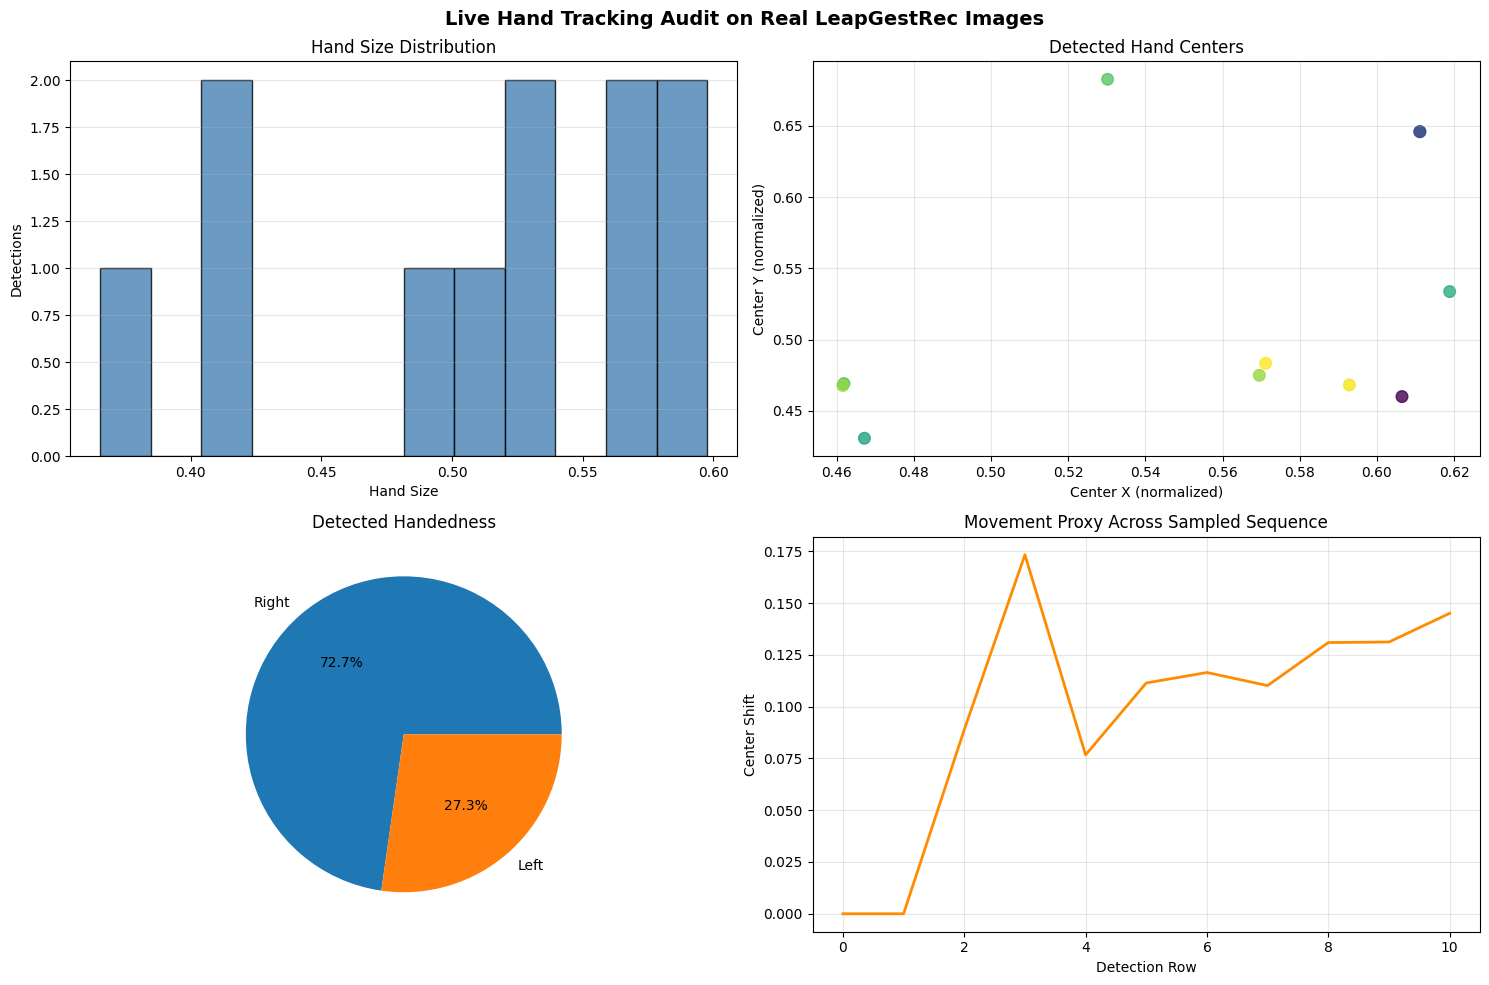

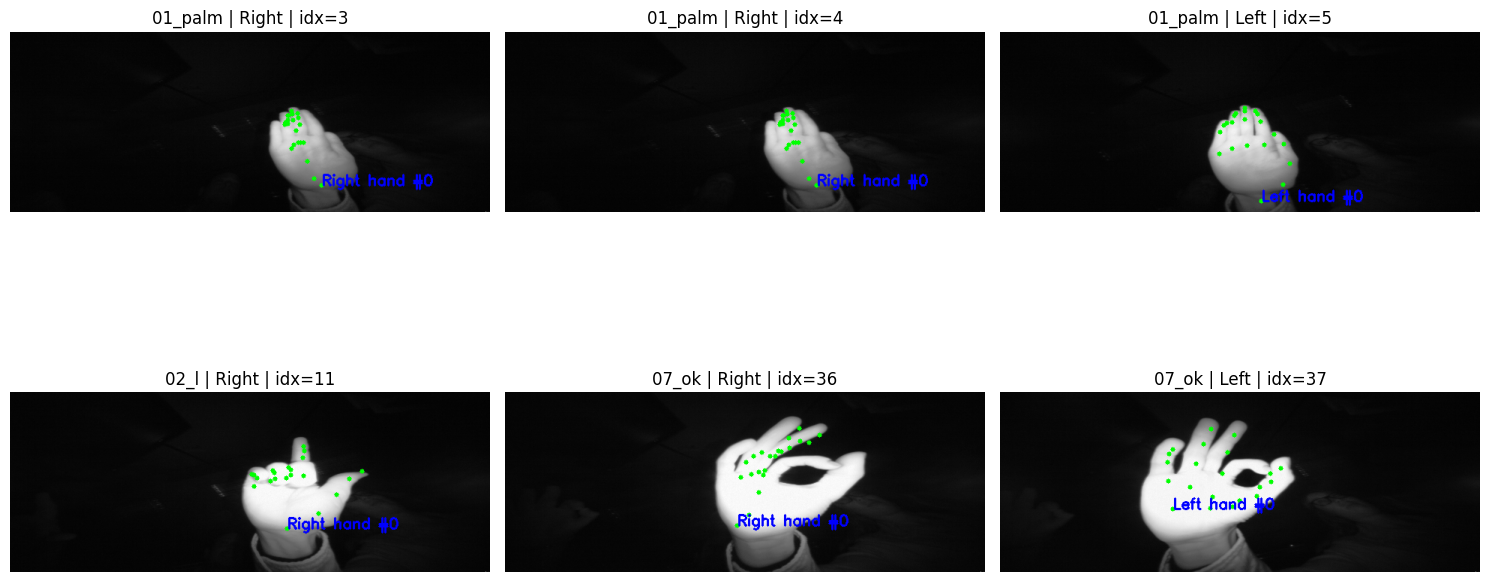

✓ Analysis plot saved to C:\Users\ahmad\hand_tracking_project\outputs\hand_tracking_analysis.png
✓ Preview plot saved to C:\Users\ahmad\hand_tracking_project\outputs\hand_tracking_previews.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Live Hand Tracking Audit on Real LeapGestRec Images', fontsize=14, fontweight='bold')

axes[0, 0].hist(results_df['hand_size'], bins=12, color='steelblue', edgecolor='black', alpha=0.8)
axes[0, 0].set_title('Hand Size Distribution')
axes[0, 0].set_xlabel('Hand Size')
axes[0, 0].set_ylabel('Detections')
axes[0, 0].grid(alpha=0.3, axis='y')

axes[0, 1].scatter(results_df['center_x'], results_df['center_y'], c=results_df['hand_size'], cmap='viridis', s=70, alpha=0.8)
axes[0, 1].set_title('Detected Hand Centers')
axes[0, 1].set_xlabel('Center X (normalized)')
axes[0, 1].set_ylabel('Center Y (normalized)')
axes[0, 1].grid(alpha=0.3)

handedness_counts = results_df['handedness'].value_counts()
axes[1, 0].pie(handedness_counts.values, labels=handedness_counts.index, autopct='%1.1f%%')
axes[1, 0].set_title('Detected Handedness')

axes[1, 1].plot(results_df['movement_proxy'].values, color='darkorange', linewidth=2)
axes[1, 1].set_title('Movement Proxy Across Sampled Sequence')
axes[1, 1].set_xlabel('Detection Row')
axes[1, 1].set_ylabel('Center Shift')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
analysis_plot_path = OUTPUT_DIR / 'hand_tracking_analysis.png'
plt.savefig(analysis_plot_path, dpi=120, bbox_inches='tight')
plt.show()

preview_plot_path = OUTPUT_DIR / 'hand_tracking_previews.png'
if preview_records:
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    axes = axes.flatten()
    for axis, preview_record in zip(axes, preview_records):
        axis.imshow(preview_record['image_rgb'])
        axis.set_title(preview_record['caption'])
        axis.axis('off')
    for axis in axes[len(preview_records):]:
        axis.axis('off')
    plt.tight_layout()
    plt.savefig(preview_plot_path, dpi=120, bbox_inches='tight')
    plt.show()
else:
    preview_plot_path = None

print(f'✓ Analysis plot saved to {analysis_plot_path}')
if preview_plot_path:
    print(f'✓ Preview plot saved to {preview_plot_path}')


## Save Results

Write the real detection table, metrics, and project manifest to disk.


In [9]:
results_csv_path = OUTPUT_DIR / 'hand_tracking_results.csv'
results_df.to_csv(results_csv_path, index=False)

metrics = {
    'project': 'Project 6 - Live Hand Tracking Module',
    'model': 'MediaPipe Hand Landmarker',
    'task_family': 'hand landmarks',
    'dataset': {
        'name': 'LeapGestRec',
        'source': 'https://www.kaggle.com/datasets/gti-upm/leapgestrecog',
        'root': str(DATASET_DIR),
        'participants_found': len(participant_ids),
        'labels_found': int(len(label_counts)),
        'images_found': int(len(image_paths)),
        'official_split': 'none provided by source',
    },
    'evaluation': {
        'sampled_images': int(len(sample_paths)),
        'images_with_hand_detection': int(images_with_hands),
        'detection_coverage_percent': round(float(detection_coverage), 4),
        'hand_detections': int(len(results_df)),
        'avg_hand_size': round(float(results_df['hand_size'].mean()), 6),
        'avg_bbox_width': round(float(results_df['bbox_width'].mean()), 6),
        'avg_bbox_height': round(float(results_df['bbox_height'].mean()), 6),
        'avg_movement_proxy': round(float(results_df['movement_proxy'].mean()), 6),
        'handedness_distribution': {str(key): int(value) for key, value in results_df['handedness'].value_counts(dropna=False).items()},
    },
    'qualitative_note': 'This notebook performs a real inference audit on image data. It reports tracking-oriented geometry proxies instead of fabricated video tracking accuracy.',
}

metrics_path = OUTPUT_DIR / 'metrics.json'
with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2)

manifest = {
    'project': 'Project 6 - Live Hand Tracking Module',
    'preferred_stack': 'MediaPipe Hand Landmarker',
    'artifacts': {
        'results_csv': str(results_csv_path),
        'metrics_json': str(metrics_path),
        'analysis_plot': str(analysis_plot_path),
        'preview_plot': str(preview_plot_path) if preview_plot_path else None,
    },
}

manifest_path = OUTPUT_DIR / 'project_manifest.json'
with open(manifest_path, 'w', encoding='utf-8') as f:
    json.dump(manifest, f, indent=2)

print(f'✓ Results table saved to {results_csv_path}')
print(f'✓ Metrics saved to {metrics_path}')
print(f'✓ Manifest saved to {manifest_path}')


✓ Results table saved to C:\Users\ahmad\hand_tracking_project\outputs\hand_tracking_results.csv
✓ Metrics saved to C:\Users\ahmad\hand_tracking_project\outputs\metrics.json
✓ Manifest saved to C:\Users\ahmad\hand_tracking_project\outputs\project_manifest.json


## Limitations and Next Steps

**What this notebook does honestly:**
- downloads the real dataset in notebook code cells
- verifies discovered labels, participant folders, and split limitations
- runs real MediaPipe hand landmark inference
- saves only real plots and artifact files produced by the run

**What it does not claim:**
- it does not claim benchmark-quality real-time video tracking metrics on an image-only dataset
- it does not fabricate object identities across frames
- it does not treat LeapGestRec gesture labels as a direct tracking benchmark

**Natural next upgrades:**
- evaluate on a true hand video dataset with frame-to-frame identity continuity
- add temporal smoothing and re-identification logic
- compare MediaPipe tracking proxies with a video-native tracker
